In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


In [4]:
## Data Reading :

query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [5]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [6]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

# Return Analysis:

### Returned vs Non-Returned Orders

In [9]:
query = """
SELECT 
    CASE 
        WHEN r.returned IS NULL THEN 'No'
        ELSE 'Yes'
    END AS returned_status,
    COUNT(DISTINCT o.order_id) AS order_count
FROM orders o
LEFT JOIN returns r
ON o.order_id = r.`Order ID`
GROUP BY returned_status;
"""
total_orders_returned = pd.read_sql(query, engine)

total_orders_returned

,returned_status,order_count
0,No,23863
1,Yes,1172


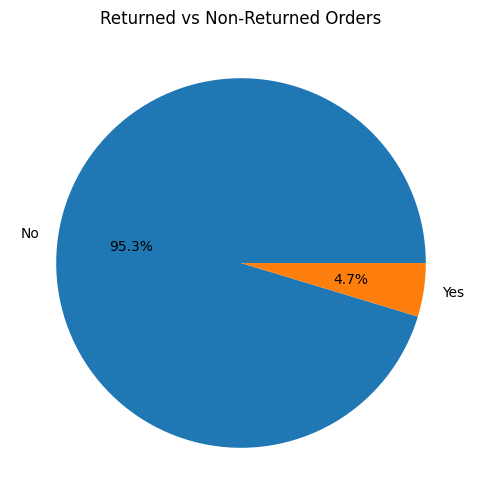

In [22]:
plt.figure(figsize=(6,6))

plt.pie(
    total_orders_returned['order_count'],
    labels=total_orders_returned['returned_status'],
    autopct='%1.1f%%'

)

plt.title('Returned vs Non-Returned Orders')

plt.show()

#autopct = show percentage on the pie chart

### Sales and profit by Return Status:

In [14]:
query = """
SELECT 
    CASE
        WHEN r.`Order ID` IS NULL THEN 'Not Returned'
        ELSE 'Returned'
    END AS returned_status,
    ROUND(SUM(o.sales), 2) AS total_sales,
    ROUND(SUM(o.profit), 2) AS total_profit
FROM orders o  
LEFT JOIN returns r  
ON o.order_id = r. `Order ID`
GROUP BY returned_status;
"""
sales_and_profit_impact_of_return = pd.read_sql(query, engine)

sales_and_profit_impact_of_return

,returned_status,total_sales,total_profit
0,Not Returned,11823486.67,1349556.70
1,Returned,819768.58,117998.67


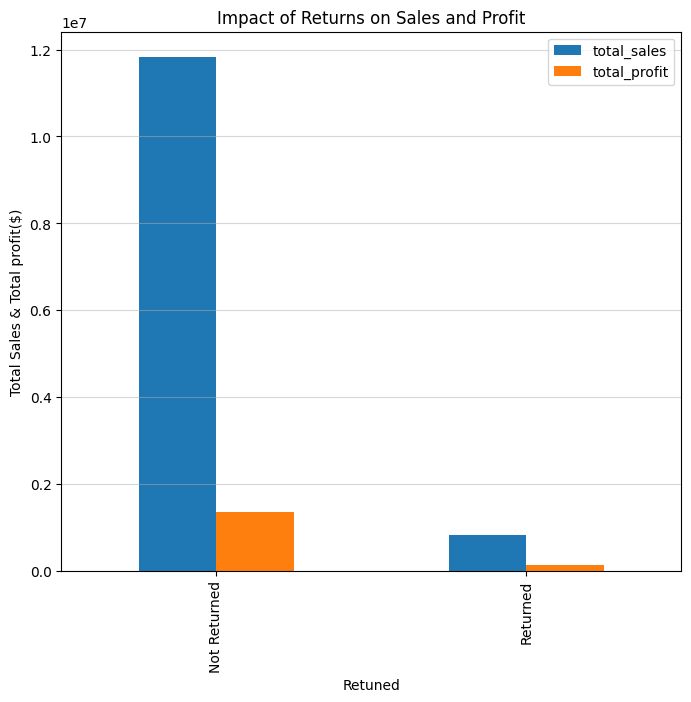

In [17]:
sales_and_profit_impact_of_return.plot(x = 'returned_status',
                                       y = ['total_sales','total_profit'],
                                       kind = 'bar',
                                      figsize = (8,7)
)

plt.title('Impact of Returns on Sales and Profit')
plt.xlabel('Retuned')
plt.ylabel('Total Sales & Total profit($)')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Returns by product category :- 

In [23]:
query = """
SELECT
    p.category,
    COUNT(DISTINCT r.`Order ID`) AS returned_orders
FROM returns r
JOIN orders o
ON r.`Order ID` = o.order_id
JOIN products p
ON o.product_id = p.product_id
WHERE r.returned = 'Yes'
GROUP BY p.category
ORDER BY returned_orders DESC;
"""
return_by_product_category = pd.read_sql(query, engine)

return_by_product_category

,category,returned_orders
0,Office Supplies,940
1,Furniture,485
2,Technology,484


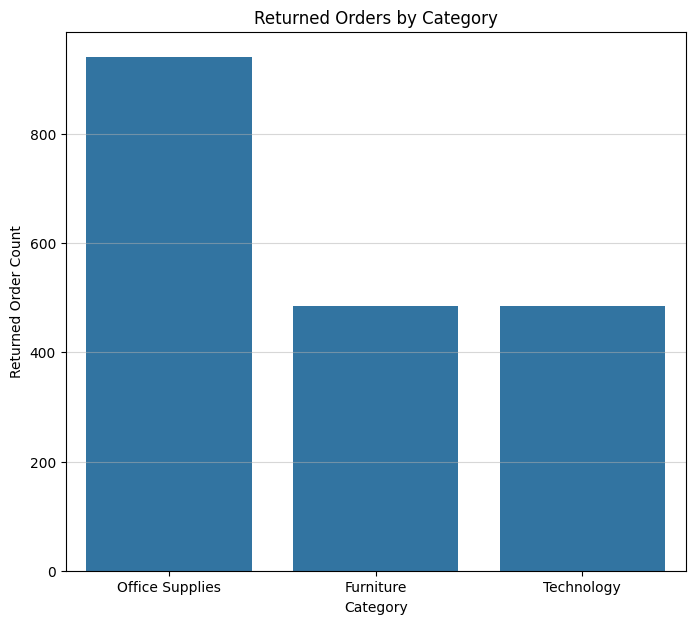

In [26]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'category',
            y = 'returned_orders',
            data = return_by_product_category
           )

plt.title('Returned Orders by Category')
plt.xlabel('Category')
plt.ylabel('Returned Order Count')
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Return by Region :-

In [27]:
query = """
SELECT 
    o.region,
    COUNT(DISTINCT r.`Order ID`) AS returned_orders
FROM returns r  
JOIN orders o 
ON r.`Order ID` = o.order_id 
WHERE r.returned = 'Yes'
GROUP BY o.Region
ORDER BY returned_orders DESC;
"""
return_by_region = pd.read_sql(query, engine)

return_by_region

,region,returned_orders
0,Central,252
1,North,236
2,West,189
3,North Asia,159
4,South,134
5,Oceania,58
6,Southeast Asia,55
7,East,45
8,Caribbean,25
9,Central Asia,24


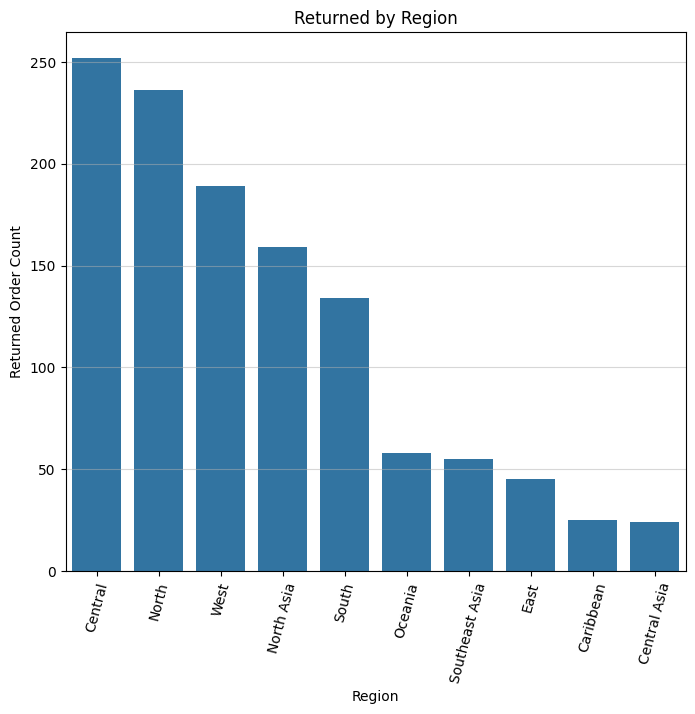

In [29]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'region',
            y = 'returned_orders',
            data = return_by_region
           )

plt.title('Returned by Region')
plt.xlabel('Region')
plt.ylabel('Returned Order Count')
plt.xticks(rotation = 75)
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Profit and Sales impact of returned orders

In [32]:
query = """
SELECT 
    ROUND(SUM(o.profit), 2) AS profit_lost_due_to_returns,
    ROUND(SUM(o.sales), 2) AS sales_lost_due_to_returns
FROM orders o 
JOIN returns r  
ON o.order_id = r.`Order ID`
WHERE r.returned = 'Yes';
"""

impact_of_returns_on_profit_and_sales = pd.read_sql(query, engine)
impact_of_returns_on_profit_and_sales

,profit_lost_due_to_returns,sales_lost_due_to_returns
0,117998.67,819768.58


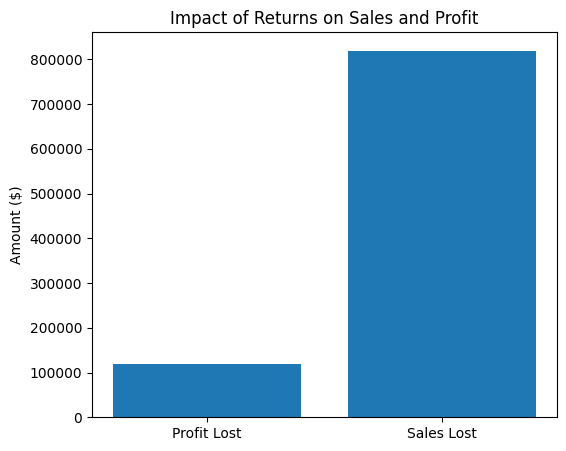

In [35]:
plt.figure(figsize=(6,5))

labels = ['Profit Lost', 'Sales Lost']
values = impact_of_returns_on_profit_and_sales.iloc[0]   #iloc 0 means extracting the first row from table

plt.bar(labels, values)

plt.title('Impact of Returns on Sales and Profit')
plt.ylabel('Amount ($)')

plt.show()

### Categories by return rate :- 

In [36]:
query = """
SELECT 
    p.category,
    COUNT(DISTINCT r.`Order ID`) AS returned_orders,
    COUNT(DISTINCT o.order_id)   AS total_orders,
    ROUND(
        COUNT(DISTINCT r.`Order ID`) * 100.00/
        COUNT(DISTINCT o.order_id),
        2
    ) AS return_rate_perct
FROM orders o
LEFT JOIN returns r  
ON o.order_id = r.`Order ID` AND r.returned = 'Yes'
JOIN products p 
ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY return_rate_perct DESC;
"""
categories_with_high_return_rate = pd.read_sql(query, engine)

categories_with_high_return_rate

,category,returned_orders,total_orders,return_rate_perct
0,Furniture,485,8195,5.92
1,Technology,484,8354,5.79
2,Office Supplies,940,19003,4.95


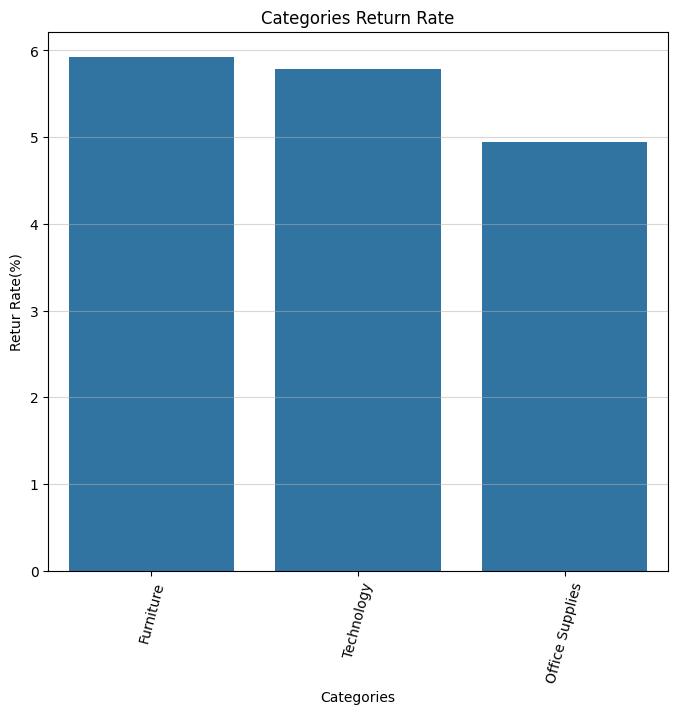

In [37]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'category',
            y = 'return_rate_perct',
            data = categories_with_high_return_rate
           )

plt.title('Categories Return Rate')
plt.xlabel('Categories')
plt.ylabel('Retur Rate(%)')
plt.xticks(rotation = 75)
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


# Summary:

## Key Insights of Return Analysis

### 1. Overall Return Rate
* **Most orders stay sold:** About **95.3%** of orders are not returned.
* **Return Percentage:** Only about **4.7%** of all orders are returned by customers.

### 2. Financial Impact
* **Lost Money:** Returns have cost the company over **$800,000 in lost sales** and more than **$100,000 in lost profit**.
* **Impact:** While the return rate is small (4.7%), the dollar amount lost is high, so it is important to keep this number low.

### 3. Returns by Category
* **Most Returned Items:** **Office Supplies** have the highest number of returned orders.
* **Return Rate Percentage:** Even though Office Supplies have more returns in total, **Furniture** has the highest "Return Rate" (nearly 6%). This means a single furniture order is more likely to be sent back than an office supply order.

### 4. Regional Trends
* **The Central Region** has the highest number of returned orders, followed by the **North** and **West** regions. 
* This matches the sales data, as these regions buy the most products, but it also means these areas need more attention to reduce shipping or product issues.

### 5. Key Takeaway
The company is losing a significant amount of profit to returns, especially in the **Furniture** category and the **Central** region. Improving product descriptions or shipping quality in these areas could help save over $100,000 in profit.